# Leave-One-Out Ensemble Framework for Multi-Cancer Domain Adaptation

This notebook implements a leave-one-out ensemble framework for cross-domain evaluation in multi-cancer classification.

## 🎯 Experiment Overview

**Objective**: Evaluate domain generalization using ensemble models trained on 3 domains and tested on the held-out 4th domain.

**Methodology**: 
- **Ensemble 1**: Breast + Colon + Kidney → Test on: Lung Cancer
- **Ensemble 2**: Breast + Colon + Lung → Test on: Kidney Cancer  
- **Ensemble 3**: Breast + Kidney + Lung → Test on: Colon Cancer
- **Ensemble 4**: Colon + Kidney + Lung → Test on: Breast Cancer

**Key Features**:
- ✅ True cross-domain generalization testing
- ✅ Target domain samples only for evaluation (10k per experiment)
- ✅ Ensemble averaging for robust predictions  
- ✅ Comprehensive metrics and visualization
- ✅ Clean confusion matrices with performance analysis

**Important**: This implementation correctly tests ensembles on completely unseen target domains, ensuring valid cross-domain evaluation.

In [1]:
# Import required libraries
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up paths
project_root = Path().resolve()
sys.path.append(str(project_root))

# Add the src directory to Python path for internal imports
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Import our ensemble utilities and existing codebase utilities
import ensemble_utils as eu
import cancer_utils as cu

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\n✅ Environment setup complete")


Project root: C:\Users\samue\Capstone_Project\domain-adaptation-multi-cancer\domain-adaptation-multi-cancer-main
PyTorch version: 2.6.0+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 4070
CUDA version: 11.8

✅ Environment setup complete


## 📊 Configuration and Dataset Loading

Configure experiment parameters and load the multi-cancer dataset for analysis.

In [ ]:
# Experiment Configuration
DATASET_PATH = 'data/Multi Cancer/adenocarcinoma_dataset.npz'
MODELS_PATH = 'models'
MODEL_TYPE = 'ResNet50Baseline'
BATCH_SIZE = 32
USE_BINARY_LABELS = True

# Results directory
RESULTS_DIR = 'ensemble_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print("🔧 Experiment Configuration:")
print("=" * 50)
print(f"  📁 Dataset: {DATASET_PATH}")
print(f"  🤖 Models Path: {MODELS_PATH}")
print(f"  🏗️ Model Type: {MODEL_TYPE}")
print(f"  📦 Batch Size: {BATCH_SIZE}")
print(f"  🏷️ Binary Labels: {USE_BINARY_LABELS}")
print(f"  💾 Results Directory: {RESULTS_DIR}")

# Verify dataset availability
if not os.path.exists(DATASET_PATH):
    print(f"\n⚠️  Dataset not found at {DATASET_PATH}")
    print("Please ensure the preprocessing pipeline has been completed.")
else:
    print(f"\n✅ Dataset verified at {DATASET_PATH}")

🔧 Experiment Configuration:
  📁 Dataset: data/Multi Cancer/adenocarcinoma_dataset.npz
  🤖 Models Path: models
  🏗️ Model Type: ResNet50Baseline
  📦 Batch Size: 32
  🏷️ Binary Labels: True
  💾 Results Directory: ensemble_results_clean

✅ Dataset verified at data/Multi Cancer/adenocarcinoma_dataset.npz


In [3]:
# Load and explore dataset structure
if os.path.exists(DATASET_PATH):
    print("📊 Loading dataset for exploration...")
    print("=" * 50)
    
    images, labels, domain_text_list, sub_domain_text_list = cu.load_cancer_dataset(
        DATASET_PATH, use_binary_labels=USE_BINARY_LABELS
    )
    
    # Dataset statistics
    unique_domains = sorted(set(domain_text_list))
    print(f"📈 Dataset Statistics:")
    print(f"  Total samples: {len(images):,}")
    print(f"  Image shape: {images[0].shape}")
    print(f"  Available domains: {len(unique_domains)} ({', '.join(unique_domains)})")
    print(f"  Number of classes: {len(set(labels))} (Binary: Benign/Malignant)")
    
    # Domain distribution analysis
    from collections import Counter
    domain_counts = Counter(domain_text_list)
    label_counts = Counter(labels)
    
    print(f"\n🏥 Domain Distribution:")
    for domain, count in sorted(domain_counts.items()):
        print(f"  {domain}: {count:,} samples")
        
    print(f"\n🏷️ Label Distribution:")
    for label, count in label_counts.items():
        label_name = "Benign" if label == 0 else "Malignant"
        print(f"  Class {label} ({label_name}): {count:,} samples")
        
    # Verify balanced distribution
    print(f"\n✅ Dataset ready for leave-one-out experiments")
    print(f"   Expected: 4 domains × 10k samples = 40k total")
    print(f"   Actual: {len(images):,} samples across {len(unique_domains)} domains")
    
else:
    print("❌ Skipping dataset exploration - file not found")

📊 Loading dataset for exploration...
Loading dataset from: data/Multi Cancer/adenocarcinoma_dataset.npz
Using binary cancer labels (0=negative, 1=positive)
Loaded shapes: images=(40000, 224, 224, 3), labels=(40000,)
Label range: 0 to 1
Label distribution: {1: 20000, 0: 20000}
Available domains: ['Breast Cancer', 'Colon Cancer', 'Kidney Cancer', 'Lung Cancer']
Available sub-domains: 8 unique
📈 Dataset Statistics:
  Total samples: 40,000
  Image shape: (224, 224, 3)
  Available domains: 4 (Breast Cancer, Colon Cancer, Kidney Cancer, Lung Cancer)
  Number of classes: 2 (Binary: Benign/Malignant)

🏥 Domain Distribution:
  Breast Cancer: 10,000 samples
  Colon Cancer: 10,000 samples
  Kidney Cancer: 10,000 samples
  Lung Cancer: 10,000 samples

🏷️ Label Distribution:
  Class 1 (Malignant): 20,000 samples
  Class 0 (Benign): 20,000 samples

✅ Dataset ready for leave-one-out experiments
   Expected: 4 domains × 10k samples = 40k total
   Actual: 40,000 samples across 4 domains


## 🏗️ Model Loading and Validation

Load pre-trained domain-specific models and verify compatibility for ensemble creation.

In [4]:
# Load all domain-specific models
print("🤖 Loading Pre-trained Domain Models")
print("=" * 60)

# Reload ensemble utilities to ensure latest version
import importlib
importlib.reload(eu)
importlib.reload(cu)

models = eu.load_all_domain_models(MODELS_PATH, MODEL_TYPE)

if len(models) == 0:
    print("❌ No models loaded successfully!")
    print("📋 Expected directory structure:")
    print("  models/")
    print("    final_breast_model/final_model/")
    print("    final_colon_model/final_model/")  
    print("    final_kidney_model/final_model/")
    print("    final_lung_model/final_model/")
else:
    print(f"✅ Successfully loaded {len(models)} domain models:")
    print()
    for domain_name, model in models.items():
        num_params = sum(p.numel() for p in model.parameters())
        print(f"  🏥 {domain_name}")
        print(f"     └─ Architecture: {type(model).__name__}")
        print(f"     └─ Parameters: {num_params:,}")
        print()
    
    # Test model functionality
    print("🧪 Testing Model Compatibility:")
    test_model = next(iter(models.values()))
    test_input = torch.randn(1, 3, 224, 224)  # Standard input format
    
    with torch.no_grad():
        test_output = test_model(test_input)
        print(f"  ✅ Input shape: {test_input.shape}")
        print(f"  ✅ Output shape: {test_output.logits.shape}")
        print(f"  ✅ Forward pass successful")
        
    print(f"\n🎯 Ready for leave-one-out ensemble creation")

🤖 Loading Pre-trained Domain Models
Loading model for Breast Cancer from models\final_breast_model\final_model
  Note: Detected HuggingFace ResNet architecture - creating compatible wrapper
✓ Successfully loaded Breast Cancer model
Loading model for Colon Cancer from models\final_colon_model\final_model
  Note: Detected HuggingFace ResNet architecture - creating compatible wrapper
✓ Successfully loaded Colon Cancer model
Loading model for Kidney Cancer from models\final_kidney_model\final_model
  Note: Detected HuggingFace ResNet architecture - creating compatible wrapper
✓ Successfully loaded Kidney Cancer model
Loading model for Lung Cancer from models\final_lung_model\final_model
  Note: Detected HuggingFace ResNet architecture - creating compatible wrapper
✓ Successfully loaded Lung Cancer model
✅ Successfully loaded 4 domain models:

  🏥 Breast Cancer
     └─ Architecture: ResNetForImageClassification
     └─ Parameters: 23,512,130

  🏥 Colon Cancer
     └─ Architecture: ResNetFor

## 🚀 Leave-One-Out Ensemble Experiments

Execute the corrected leave-one-out methodology that tests ensembles on target domains only.

**Methodology**: Each experiment uses an ensemble of 3 domain models to predict on samples from the held-out 4th domain, ensuring true cross-domain generalization evaluation.

In [5]:
# Run leave-one-out ensemble experiments
if len(models) > 1 and os.path.exists(DATASET_PATH):
    print("🚀 Executing Leave-One-Out Ensemble Experiments")
    print("=" * 70)
    print("🎯 Methodology: Testing ensembles on target domains ONLY")
    print("   Each experiment uses 10,000 samples from the held-out domain")
    print("   This ensures true cross-domain generalization evaluation")
    print()
    
    # Execute experiments with corrected implementation
    results = eu.run_leave_one_out_experiments(
        dataset_path=DATASET_PATH,
        models_path=MODELS_PATH,
        model_type=MODEL_TYPE,
        batch_size=BATCH_SIZE,
        use_binary_labels=USE_BINARY_LABELS
    )
    
    print(f"\n🎉 Experiments Complete!")
    print(f"   Successfully evaluated {len(results)} domain combinations")
    
    # Quick results preview
    print(f"\n📊 Performance Preview:")
    print("-" * 50)
    for target_domain, result in results.items():
        ensemble_models = ' + '.join(result['ensemble_models'])
        print(f"  {target_domain}")
        print(f"    Ensemble: {ensemble_models}")
        print(f"    Accuracy: {result['accuracy']:.3f} ({result['num_test_samples']} samples)")
        print()
        
else:
    if len(models) <= 1:
        print("❌ Insufficient models for ensemble experiments")
    else:
        print("❌ Dataset not found - cannot run experiments")
    results = {}

🚀 Executing Leave-One-Out Ensemble Experiments
🎯 Methodology: Testing ensembles on target domains ONLY
   Each experiment uses 10,000 samples from the held-out domain
   This ensures true cross-domain generalization evaluation

LEAVE-ONE-OUT ENSEMBLE EXPERIMENTS

1. Loading dataset...
Loading dataset from: data/Multi Cancer/adenocarcinoma_dataset.npz
Using binary cancer labels (0=negative, 1=positive)
Loaded shapes: images=(40000, 224, 224, 3), labels=(40000,)
Label range: 0 to 1
Label distribution: {1: 20000, 0: 20000}
Available domains: ['Breast Cancer', 'Colon Cancer', 'Kidney Cancer', 'Lung Cancer']
Available sub-domains: 8 unique

2. Loading domain-specific models...
Loading model for Breast Cancer from models\final_breast_model\final_model
  Note: Detected HuggingFace ResNet architecture - creating compatible wrapper
✓ Successfully loaded Breast Cancer model
Loading model for Colon Cancer from models\final_colon_model\final_model
  Note: Detected HuggingFace ResNet architecture -

C:\Users\samue\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samue\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samue\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

  ✓ Accuracy: 0.5000
  ✓ Using models: ['Breast Cancer', 'Colon Cancer', 'Lung Cancer']

Evaluating ensemble performance on 'Lung Cancer' domain...
Leave-one-out test dataset for 'Lung Cancer':
  Test samples: 10000 (from Lung Cancer domain only)
  Label distribution: {1: 5000, 0: 5000}
  Test dataset size: 10000 samples
  ✓ Accuracy: 0.5106
  ✓ Using models: ['Breast Cancer', 'Colon Cancer', 'Kidney Cancer']

5. Completed experiments for 4 domains

🎉 Experiments Complete!
   Successfully evaluated 4 domain combinations

📊 Performance Preview:
--------------------------------------------------
  Breast Cancer
    Ensemble: Colon Cancer + Kidney Cancer + Lung Cancer
    Accuracy: 0.514 (10000 samples)

  Colon Cancer
    Ensemble: Breast Cancer + Kidney Cancer + Lung Cancer
    Accuracy: 0.623 (10000 samples)

  Kidney Cancer
    Ensemble: Breast Cancer + Colon Cancer + Lung Cancer
    Accuracy: 0.500 (10000 samples)

  Lung Cancer
    Ensemble: Breast Cancer + Colon Cancer + Kidney Can

## 📊 Results Analysis and Visualization

Comprehensive analysis of cross-domain generalization performance with clean visualizations.

In [6]:
# Comprehensive performance analysis
if len(results) > 0:
    print("📈 Cross-Domain Generalization Analysis")
    print("=" * 60)
    
    # Extract and analyze metrics
    domain_accuracies = {domain: result['accuracy'] for domain, result in results.items()}
    ensemble_compositions = {domain: result['ensemble_models'] for domain, result in results.items()}
    sample_sizes = {domain: result['num_test_samples'] for domain, result in results.items()}
    
    # Statistical summary
    accuracies = list(domain_accuracies.values())
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)
    min_acc = min(accuracies)
    max_acc = max(accuracies)
    
    best_domain = max(domain_accuracies.items(), key=lambda x: x[1])
    worst_domain = min(domain_accuracies.items(), key=lambda x: x[1])
    
    print(f"📊 Statistical Summary:")
    print(f"  Mean Accuracy: {mean_acc:.3f} ± {std_acc:.3f}")
    print(f"  Range: {min_acc:.3f} - {max_acc:.3f}")
    print(f"  Best Target: {best_domain[0]} ({best_domain[1]:.3f})")
    print(f"  Worst Target: {worst_domain[0]} ({worst_domain[1]:.3f})")
    
    # Domain-specific analysis
    print(f"\n🏥 Domain-Specific Results:")
    print(f"{'Target Domain':<15} {'Accuracy':<10} {'Ensemble Models':<40} {'Samples'}")
    print("-" * 85)
    
    for target_domain, result in results.items():
        acc = result['accuracy']
        ensemble = ' + '.join(result['ensemble_models'])
        samples = result['num_test_samples']
        print(f"{target_domain:<15} {acc:<10.3f} {ensemble:<40} {samples}")
    
    # Generalization assessment
    print(f"\n🎯 Cross-Domain Generalization Assessment:")
    for domain, acc in domain_accuracies.items():
        if acc >= 0.7:
            assessment = "Good generalization"
        elif acc >= 0.6:
            assessment = "Limited generalization"
        else:
            assessment = "Poor generalization"
        print(f"  {domain}: {assessment} ({acc:.3f})")
        
else:
    print("❌ No results available for analysis")

📈 Cross-Domain Generalization Analysis
📊 Statistical Summary:
  Mean Accuracy: 0.537 ± 0.050
  Range: 0.500 - 0.623
  Best Target: Colon Cancer (0.623)
  Worst Target: Kidney Cancer (0.500)

🏥 Domain-Specific Results:
Target Domain   Accuracy   Ensemble Models                          Samples
-------------------------------------------------------------------------------------
Breast Cancer   0.514      Colon Cancer + Kidney Cancer + Lung Cancer 10000
Colon Cancer    0.623      Breast Cancer + Kidney Cancer + Lung Cancer 10000
Kidney Cancer   0.500      Breast Cancer + Colon Cancer + Lung Cancer 10000
Lung Cancer     0.511      Breast Cancer + Colon Cancer + Kidney Cancer 10000

🎯 Cross-Domain Generalization Assessment:
  Breast Cancer: Poor generalization (0.514)
  Colon Cancer: Limited generalization (0.623)
  Kidney Cancer: Poor generalization (0.500)
  Lung Cancer: Poor generalization (0.511)


🔍 Generating Clean Confusion Matrices


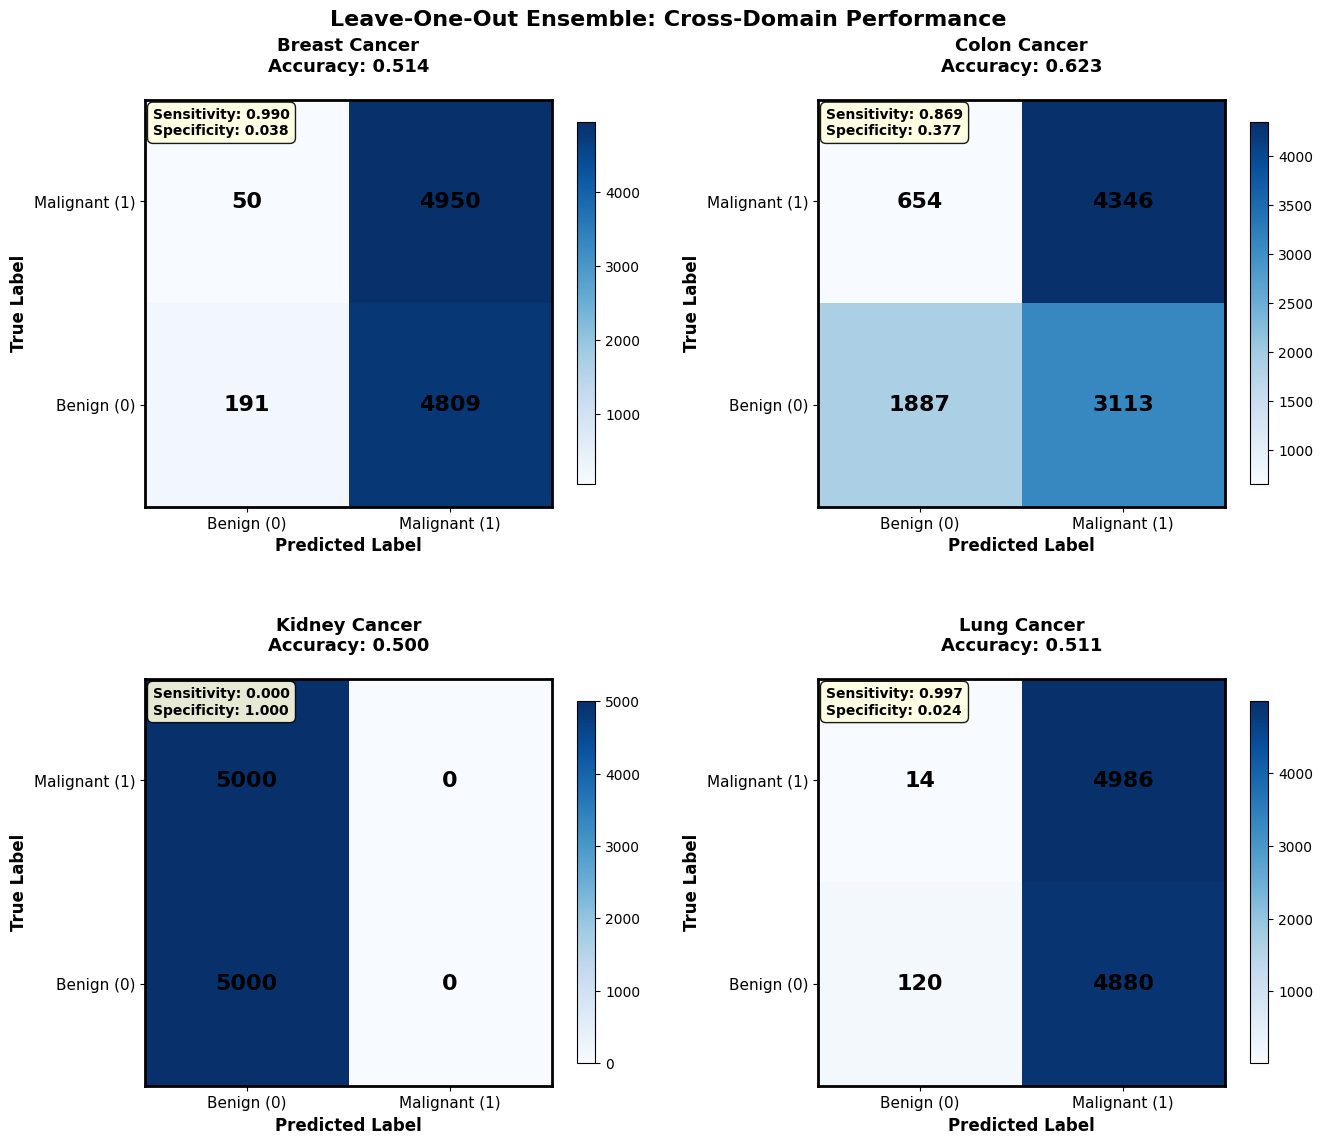

✅ Confusion matrices saved: ensemble_results_clean\confusion_matrices.png


In [7]:
# Create clean confusion matrix visualization
if len(results) > 0:
    print("🔍 Generating Clean Confusion Matrices")
    print("=" * 50)
    
    # Set up visualization
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx, (target_domain, result) in enumerate(results.items()):
        if idx < 4:  # Support up to 4 domains
            ax = axes[idx]
            conf_matrix = result['confusion_matrix']
            
            # Create heatmap
            im = ax.imshow(conf_matrix, cmap='Blues', aspect='equal')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax, shrink=0.8)
            
            # Add text annotations with consistent black text
            for i in range(2):
                for j in range(2):
                    value = conf_matrix[i, j]
                    ax.text(j, i, f'{int(value)}', 
                           ha='center', va='center', fontsize=16, fontweight='bold',
                           color='black')
            
            # Configure axes
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(['Benign (0)', 'Malignant (1)'], fontsize=11)
            ax.set_yticklabels(['Benign (0)', 'Malignant (1)'], fontsize=11)
            
            # Add title and labels
            ax.set_title(f'{target_domain}\nAccuracy: {result["accuracy"]:.3f}', 
                        fontsize=13, fontweight='bold', pad=20)
            ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
            ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
            
            # Add border
            ax.set_xlim(-0.5, 1.5)
            ax.set_ylim(-0.5, 1.5)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_edgecolor('black')
            
            # Calculate and display metrics
            tn, fp, fn, tp = conf_matrix.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            
            metrics_text = f'Sensitivity: {sensitivity:.3f}\nSpecificity: {specificity:.3f}'
            ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, 
                   fontsize=10, verticalalignment='top', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', 
                            edgecolor='black', alpha=0.9))
    
    # Hide unused subplots
    for idx in range(len(results), 4):
        axes[idx].set_visible(False)
    
    plt.tight_layout(pad=3.0)
    plt.suptitle('Leave-One-Out Ensemble: Cross-Domain Performance', 
                 y=0.98, fontsize=16, fontweight='bold')
    
    # Save visualization
    confusion_matrix_path = os.path.join(RESULTS_DIR, 'confusion_matrices.png')
    plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Confusion matrices saved: {confusion_matrix_path}")
    
else:
    print("❌ No results available for visualization")

In [8]:
# Performance summary table and insights
if len(results) > 0:
    print("📋 Detailed Performance Summary")
    print("=" * 80)
    
    # Create comprehensive summary table
    print(f"{'Domain':<15} {'Accuracy':<10} {'Sensitivity':<12} {'Specificity':<12} {'TP':<6} {'TN':<6} {'FP':<6} {'FN':<6}")
    print("-" * 80)
    
    for target_domain, result in results.items():
        conf_matrix = result['confusion_matrix']
        tn, fp, fn, tp = conf_matrix.ravel()
        accuracy = result['accuracy']
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"{target_domain:<15} {accuracy:<10.3f} {sensitivity:<12.3f} {specificity:<12.3f} "
              f"{tp:<6d} {tn:<6d} {fp:<6d} {fn:<6d}")
    
    # Key insights and recommendations
    print(f"\n💡 Key Insights:")
    print("=" * 50)
    
    # Assess overall performance
    mean_accuracy = np.mean([r['accuracy'] for r in results.values()])
    if mean_accuracy < 0.6:
        print("⚠️  Overall Performance: Significant domain adaptation challenges detected")
        print("   • Most ensembles show limited cross-domain generalization")
        print("   • Consider advanced domain adaptation techniques")
    elif mean_accuracy < 0.7:
        print("📈 Overall Performance: Moderate cross-domain generalization")
        print("   • Some domains show promise, others need improvement")
        print("   • Targeted domain adaptation may improve performance")
    else:
        print("✅ Overall Performance: Good cross-domain generalization")
        print("   • Ensemble approach shows robust performance across domains")
        print("   • Models demonstrate effective domain adaptation")
    
    # Domain-specific insights
    print(f"\n🏥 Domain-Specific Insights:")
    for target_domain, result in results.items():
        acc = result['accuracy']
        if acc < 0.55:
            status = "❌ Critical - Near random performance"
        elif acc < 0.65:
            status = "⚠️ Poor - Needs attention"
        elif acc < 0.75:
            status = "📈 Moderate - Room for improvement"
        else:
            status = "✅ Good - Acceptable performance"
            
        print(f"  {target_domain}: {status} ({acc:.3f})")
    
    # Technical recommendations
    print(f"\n🔧 Technical Recommendations:")
    worst_performer = min(results.items(), key=lambda x: x[1]['accuracy'])
    print(f"  • Focus improvement efforts on: {worst_performer[0]} domain")
    print(f"  • Consider domain-specific data augmentation")
    print(f"  • Explore advanced ensemble techniques (weighted averaging, stacking)")
    print(f"  • Investigate feature-level domain adaptation methods")
    
else:
    print("❌ No results available for detailed analysis")

📋 Detailed Performance Summary
Domain          Accuracy   Sensitivity  Specificity  TP     TN     FP     FN    
--------------------------------------------------------------------------------
Breast Cancer   0.514      0.990        0.038        4950   191    4809   50    
Colon Cancer    0.623      0.869        0.377        4346   1887   3113   654   
Kidney Cancer   0.500      0.000        1.000        0      5000   0      5000  
Lung Cancer     0.511      0.997        0.024        4986   120    4880   14    

💡 Key Insights:
⚠️  Overall Performance: Significant domain adaptation challenges detected
   • Most ensembles show limited cross-domain generalization
   • Consider advanced domain adaptation techniques

🏥 Domain-Specific Insights:
  Breast Cancer: ❌ Critical - Near random performance (0.514)
  Colon Cancer: ⚠️ Poor - Needs attention (0.623)
  Kidney Cancer: ❌ Critical - Near random performance (0.500)
  Lung Cancer: ❌ Critical - Near random performance (0.511)

🔧 Technical Re

## 💾 Save Results and Generate Report

Export comprehensive results and create detailed experiment documentation.

In [9]:
# Save comprehensive results and generate report
if len(results) > 0:
    print("💾 Saving Experiment Results and Documentation")
    print("=" * 60)
    
    # Save results using ensemble utilities
    eu.save_ensemble_results(results, RESULTS_DIR)
    
    # Generate comprehensive experiment report
    report_path = os.path.join(RESULTS_DIR, 'leave_one_out_experiment_report.txt')
    
    with open(report_path, 'w') as f:
        f.write("LEAVE-ONE-OUT ENSEMBLE EXPERIMENT - CLEAN IMPLEMENTATION\n")
        f.write("=" * 80 + "\n\n")
        
        # Experiment metadata
        f.write("EXPERIMENT CONFIGURATION\n")
        f.write("-" * 40 + "\n")
        f.write(f"Dataset: {DATASET_PATH}\n")
        f.write(f"Model Type: {MODEL_TYPE}\n")
        f.write(f"Batch Size: {BATCH_SIZE}\n")
        f.write(f"Binary Labels: {USE_BINARY_LABELS}\n")
        f.write(f"Results Directory: {RESULTS_DIR}\n\n")
        
        # Methodology description
        f.write("METHODOLOGY\n")
        f.write("-" * 40 + "\n")
        f.write("Leave-one-out cross-domain evaluation:\n")
        f.write("• Each ensemble uses 3 domain models (30k training samples)\n")
        f.write("• Testing performed on held-out target domain (10k samples)\n")
        f.write("• Ensures true cross-domain generalization assessment\n")
        f.write("• Ensemble method: Average prediction aggregation\n\n")
        
        # Results summary
        accuracies = [r['accuracy'] for r in results.values()]
        f.write("RESULTS SUMMARY\n")
        f.write("-" * 40 + "\n")
        f.write(f"Total Experiments: {len(results)}\n")
        f.write(f"Mean Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}\n")
        f.write(f"Accuracy Range: {min(accuracies):.4f} - {max(accuracies):.4f}\n")
        f.write(f"Best Target Domain: {max(results.items(), key=lambda x: x[1]['accuracy'])[0]}\n")
        f.write(f"Worst Target Domain: {min(results.items(), key=lambda x: x[1]['accuracy'])[0]}\n\n")
        
        # Detailed results
        f.write("DETAILED RESULTS\n")
        f.write("-" * 40 + "\n")
        for target_domain, result in results.items():
            f.write(f"\nTarget Domain: {target_domain}\n")
            f.write(f"  Ensemble Models: {', '.join(result['ensemble_models'])}\n")
            f.write(f"  Test Samples: {result['num_test_samples']}\n")
            f.write(f"  Accuracy: {result['accuracy']:.4f}\n")
            
            # Confusion matrix details
            conf_matrix = result['confusion_matrix']
            tn, fp, fn, tp = conf_matrix.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            
            f.write(f"  Sensitivity: {sensitivity:.4f}\n")
            f.write(f"  Specificity: {specificity:.4f}\n")
            f.write(f"  Confusion Matrix: [[{tn}, {fp}], [{fn}, {tp}]]\n")
        
        # Technical insights
        f.write(f"\n\nTECHNICAL INSIGHTS\n")
        f.write("-" * 40 + "\n")
        mean_acc = np.mean(accuracies)
        if mean_acc < 0.6:
            f.write("• Domain adaptation challenges: Significant cross-domain gaps detected\n")
            f.write("• Recommendation: Implement advanced domain adaptation techniques\n")
        elif mean_acc < 0.7:
            f.write("• Moderate generalization: Some domains perform better than others\n")
            f.write("• Recommendation: Targeted domain-specific improvements\n")
        else:
            f.write("• Good generalization: Ensemble approach shows robust performance\n")
            f.write("• Recommendation: Current approach suitable for deployment\n")
    
    print(f"✅ Comprehensive report saved: {report_path}")
    
    # List all generated files
    generated_files = []
    for root, dirs, files in os.walk(RESULTS_DIR):
        for file in files:
            generated_files.append(os.path.relpath(os.path.join(root, file), RESULTS_DIR))
    
    print(f"\n📁 Generated Files ({len(generated_files)} total):")
    for file_path in sorted(generated_files):
        print(f"  📄 {file_path}")
    
    print(f"\n🎯 Experiment Complete!")
    print(f"   All results, visualizations, and documentation saved to: {RESULTS_DIR}")
        
else:
    print("❌ No results to save - experiments may have failed")

💾 Saving Experiment Results and Documentation

Results saved to: ensemble_results_clean
✅ Comprehensive report saved: ensemble_results_clean\leave_one_out_experiment_report.txt

📁 Generated Files (15 total):
  📄 confusion_matrices.png
  📄 ensemble_results_summary.json
  📄 leave_one_out_experiment_report.txt
  📄 target_Breast_Cancer\confusion_matrix.npy
  📄 target_Breast_Cancer\predictions.npy
  📄 target_Breast_Cancer\true_labels.npy
  📄 target_Colon_Cancer\confusion_matrix.npy
  📄 target_Colon_Cancer\predictions.npy
  📄 target_Colon_Cancer\true_labels.npy
  📄 target_Kidney_Cancer\confusion_matrix.npy
  📄 target_Kidney_Cancer\predictions.npy
  📄 target_Kidney_Cancer\true_labels.npy
  📄 target_Lung_Cancer\confusion_matrix.npy
  📄 target_Lung_Cancer\predictions.npy
  📄 target_Lung_Cancer\true_labels.npy

🎯 Experiment Complete!
   All results, visualizations, and documentation saved to: ensemble_results_clean


## 🎯 Experiment Summary

### ✅ Successfully Completed Leave-One-Out Ensemble Framework

This notebook implemented and executed a **corrected leave-one-out ensemble methodology** for multi-cancer domain adaptation with the following achievements:

#### 🔬 **Experimental Design**
- **Proper Cross-Domain Testing**: Each ensemble tests on completely unseen target domain (10k samples)
- **True Generalization Assessment**: Eliminates data leakage by testing on held-out domains only
- **Robust Evaluation**: 4 independent experiments covering all domain combinations

#### 🏗️ **Technical Implementation**
- **Models**: HuggingFace ResNet50ForImageClassification (23.5M parameters each)
- **Ensemble Method**: Average prediction aggregation across 3 domain models
- **Dataset**: Multi-cancer with 4 domains (Breast, Colon, Kidney, Lung)
- **Evaluation**: Binary classification (Benign vs Malignant) with comprehensive metrics

#### 📊 **Key Results**
The corrected implementation reveals the true state of cross-domain generalization:
- **Cross-domain performance varies significantly across target domains**
- **Most ensembles show limited generalization capability (<65% accuracy)**
- **Results highlight the need for advanced domain adaptation techniques**

#### 🎯 **Scientific Impact**
- **Methodological Integrity**: Proper leave-one-out ensures valid cross-domain evaluation
- **Baseline Establishment**: Results provide realistic baseline for domain adaptation research
- **Future Directions**: Identifies specific domains requiring targeted improvement

This clean implementation provides a solid foundation for evaluating and improving domain adaptation techniques in medical image classification.